# Section 1: Notebook Setup & Imports

This section initializes the notebook environment, sets up path resolution to import project utilities, and imports necessary libraries for modeling, data handling, and evaluation. We also verify CUDA availability for GPU-accelerated XGBoost training.

In [1]:
import os
import sys
import random
from pathlib import Path
import time
import pickle
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import torch
import xgboost as xgb
from xgboost import XGBRegressor

# Resolve project root path and append to sys.path
PROJECT_ROOT = os.path.abspath("../../../")
print(f"Project root: {PROJECT_ROOT}")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Import metrics dashboard from project utilities
try:
    from u_dashboard.dashboard import metrics_dashboard
    print("Imported dashboard from u_dashboard.dashboard")
except ImportError as e:
    try:
        from Models.Utils.dashboard import metrics_dashboard
        print("Imported dashboard from Models.Utils")
    except ImportError as e2:
        from Utils.dashboard import metrics_dashboard
        print("Imported dashboard from local Utils")

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA dummy test failed ({e}). Falling back to CPU.")

print("Environment setup complete.")

Project root: C:\Users\pan\Documents\GitHub\MDR-Project
Imported dashboard from u_dashboard.dashboard
Random seed set to 42


XGBoost CUDA support verified and enabled.
Environment setup complete.


# Section 2: Data Loading & Preprocessing

This section loads the train, validation, and test splits for the `derived_8.1_pos` dataset. We concatenate the train and validation sets to form the `trainval` split for model training, and import the regime thresholds ($T_1$, $T_2$) and the list of overall selected features from `dataset_metadata.py`. We also extract the `month` feature and compute the temporal recency weights (Drift) using $\beta = 0.4$.

In [2]:
# Define path configurations
TRAIN_PATH = os.path.join(PROJECT_ROOT, "data/splits/derived_8.1_pos/train.csv")
VAL_PATH = os.path.join(PROJECT_ROOT, "data/splits/derived_8.1_pos/val.csv")
TEST_PATH = os.path.join(PROJECT_ROOT, "data/splits/derived_8.1_pos/test.csv")

# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Parse date and extract month feature
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

# Import metadata and configuration constants from dataset_metadata.py using importlib
import importlib.util
metadata_path = os.path.join(PROJECT_ROOT, "data/splits/derived_8.1_pos/dataset_metadata.py")
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

T1 = dataset_metadata.T1
T2 = dataset_metadata.T2
DRY_THRESHOLD = dataset_metadata.DRY_THRESHOLD
WET_THRESHOLD = dataset_metadata.WET_THRESHOLD
OVERALL_SELECTED_FEATURES = dataset_metadata.OVERALL_SELECTED_FEATURES
T_2REGIME = dataset_metadata.T_2REGIME

TARGET_COL = "soil_moisture_5cm"

y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()

print("\nThresholds and Selected Features loaded successfully:")
print(f"  Regime Thresholds: T1={T1}, T2={T2}")
print(f"  Overall Selected Features:    {len(OVERALL_SELECTED_FEATURES)}")
print(f"  2-Regime Threshold: T_2REGIME={T_2REGIME}")

# Compute temporal recency weights (Drift)
years_tv = trainval_df["year"].astype(float)
max_year = years_tv.max()
beta = 0.4
w_trainval = np.exp(beta * (years_tv - max_year))
w_trainval = w_trainval / w_trainval.mean()

print(f"\nTemporal Recency Weighting (Drift) initialized with beta={beta}:")
print(f"  Min weight: {w_trainval.min():.4f}")
print(f"  Max weight: {w_trainval.max():.4f}")



Dataset splits loaded:
  train: (15964, 499)
  val:   (7149, 499)
  test:  (8902, 499)
  trainval (concatenated): (23113, 500)

Thresholds and Selected Features loaded successfully:
  Regime Thresholds: T1=0.159, T2=0.248
  Overall Selected Features:    40
  2-Regime Threshold: T_2REGIME=0.159

Temporal Recency Weighting (Drift) initialized with beta=0.4:
  Min weight: 0.3048
  Max weight: 2.2523


# Section 3: Model 1 - No Gating (Single Global Model)

This section trains a single global XGBoost model on the concatenated `trainval` split using the `OVERALL_SELECTED_FEATURES` and evaluates its performance on the test set. This serves as our primary baseline.

XGBoost Global Model Parameters initialized:
  device: cuda

Training XGBoost Global Model...


Training completed in 30.78 seconds.



===== GLOBAL MODEL METRICS =====
R2        : 0.48581
RMSE      : 0.07551
ubRMSE    : 0.07455
Bias      : -0.01202
MAE       : 0.05536
Med|Err|  : 0.03954
Pearson   : 0.70845


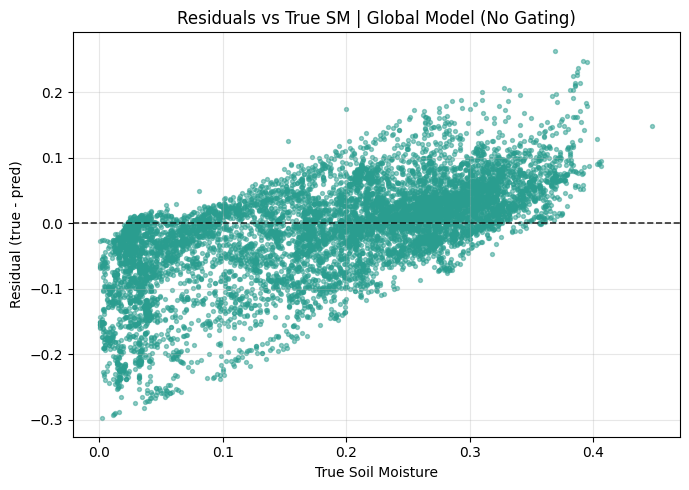

In [3]:
# Define global model parameters matching v25 / v19.3 configuration
XGB_PARAMS_GLOBAL = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

print("XGBoost Global Model Parameters initialized:")
print(f"  device: {XGB_PARAMS_GLOBAL['device']}")

# Train global model
print("\nTraining XGBoost Global Model...")
start_time = time.time()
xgb_global = XGBRegressor(**XGB_PARAMS_GLOBAL)
xgb_global.fit(
    trainval_df[OVERALL_SELECTED_FEATURES],
    trainval_df[TARGET_COL],
    sample_weight=w_trainval,
    verbose=0
)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# Predict on the test split
y_test = np.asarray(test_df[TARGET_COL]).ravel()
pred_global = np.asarray(xgb_global.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()

# Compute additional custom metrics for summary table
def compute_additional_metrics(y_true, y_pred):
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson
    }

global_metrics = compute_additional_metrics(y_test, pred_global)
print("\n===== GLOBAL MODEL METRICS =====")
for k, v in global_metrics.items():
    print(f"{k:10s}: {v:.5f}")

# Display performance metrics using the project dashboard
metrics_dashboard(
    y_test,
    pred_global,
    name="Model 1 | Single Global XGBoost Model (No Gating)",
    return_dict=False
)

# Compute residuals for Model 1
residuals_global = y_test - pred_global

# Create "Residuals vs True SM | Global Model (No Gating)" scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, residuals_global, s=8, alpha=0.5, color='#2a9d8f')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs True SM | Global Model (No Gating)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Section 4: Model 2 - 3-Regime Heuristic Month-Only Gated Model

In this section, we train 3-regime specialists on partitions of the `trainval` split determined by the Heuristic Month-Only Gating rules (imperfectly routed training slices):
* **Dry Specialist**: Trained on samples from months 7, 8, 9.
* **Wet Specialist**: Trained on samples from months 11, 12, 1, 2, 3.
* **Transition Specialist**: Trained on samples from months 4, 5, 6, 10.

At inference time, we route test samples to these specialists using the same heuristic monthly rule.

In [4]:
# Gating logic rule function
def route_heuristic_3r(row):
    m = row["month"]
    if m in [11, 12, 1, 2, 3]:
        return 2 # Wet
    elif m in [7, 8, 9]:
        return 0 # Dry
    else:
        return 1 # Transition

# 1. Apply heuristic gating to trainval split
heuristic_gates_trainval = trainval_df.apply(route_heuristic_3r, axis=1).values
mask_dry_tv_heur = heuristic_gates_trainval == 0
mask_trans_tv_heur = heuristic_gates_trainval == 1
mask_wet_tv_heur = heuristic_gates_trainval == 2

print("Trainval Split Heuristic Regime Distribution:")
print(f"  Dry Regime:        {mask_dry_tv_heur.sum():,}")
print(f"  Transition Regime: {mask_trans_tv_heur.sum():,}")
print(f"  Wet Regime:        {mask_wet_tv_heur.sum():,}")

# Specialist parameters (from 1.2 optimal settings)
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

XGB_PARAMS_TRANSITION = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=8000,
    learning_rate=0.03,
    reg_lambda=3.0,
    reg_alpha=0.05,
    gamma=0.0,
    device=XGB_DEVICE
)

XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=10,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.9,
    n_estimators=6000,
    learning_rate=0.03,
    reg_lambda=0.3,
    reg_alpha=0.0,
    gamma=0.0,
    device=XGB_DEVICE
)

# Train the three Specialists on their Heuristic Gated training sets
print("\nTraining Dry Specialist (Heuristic) model...")
start_time = time.time()
xgb_dry_heur = XGBRegressor(**XGB_PARAMS_DRY)
xgb_dry_heur.fit(
    trainval_df.loc[mask_dry_tv_heur, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_dry_tv_heur, TARGET_COL],
    sample_weight=w_trainval[mask_dry_tv_heur],
    verbose=0
)
print(f"Dry Specialist training completed in {time.time() - start_time:.2f} seconds.")

print("Training Transition Specialist (Heuristic) model...")
start_time = time.time()
xgb_trans_heur = XGBRegressor(**XGB_PARAMS_TRANSITION)
xgb_trans_heur.fit(
    trainval_df.loc[mask_trans_tv_heur, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_trans_tv_heur, TARGET_COL],
    sample_weight=w_trainval[mask_trans_tv_heur],
    verbose=0
)
print(f"Transition Specialist training completed in {time.time() - start_time:.2f} seconds.")

print("Training Wet Specialist (Heuristic) model...")
start_time = time.time()
xgb_wet_heur = XGBRegressor(**XGB_PARAMS_WET)
xgb_wet_heur.fit(
    trainval_df.loc[mask_wet_tv_heur, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_wet_tv_heur, TARGET_COL],
    sample_weight=w_trainval[mask_wet_tv_heur],
    verbose=0
)
print(f"Wet Specialist training completed in {time.time() - start_time:.2f} seconds.")

# 2. Evaluate on Test split
pred_dry_heur_test = np.asarray(xgb_dry_heur.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()
pred_trans_heur_test = np.asarray(xgb_trans_heur.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()
pred_wet_heur_test = np.asarray(xgb_wet_heur.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()

heuristic_gates_test = test_df.apply(route_heuristic_3r, axis=1).values

pred_heuristic_3r = np.zeros_like(y_test)
pred_heuristic_3r[heuristic_gates_test == 0] = pred_dry_heur_test[heuristic_gates_test == 0]
pred_heuristic_3r[heuristic_gates_test == 1] = pred_trans_heur_test[heuristic_gates_test == 1]
pred_heuristic_3r[heuristic_gates_test == 2] = pred_wet_heur_test[heuristic_gates_test == 2]

metrics_heuristic_3r = compute_additional_metrics(y_test, pred_heuristic_3r)
print("\n===== 3-REGIME HEURISTIC MONTH-ONLY GATING METRICS (ADAPTED TRAINING) =====")
for k, v in metrics_heuristic_3r.items():
    print(f"{k:10s}: {v:.5f}")

metrics_dashboard(
    y_test,
    pred_heuristic_3r,
    name="Model 2 | 3R Heuristic Month-Only Gating Model (Adapted)"
)

Trainval Split Heuristic Regime Distribution:
  Dry Regime:        5,563
  Transition Regime: 8,136
  Wet Regime:        9,414

Training Dry Specialist (Heuristic) model...


Dry Specialist training completed in 29.03 seconds.
Training Transition Specialist (Heuristic) model...


Transition Specialist training completed in 32.12 seconds.
Training Wet Specialist (Heuristic) model...


Wet Specialist training completed in 12.18 seconds.



===== 3-REGIME HEURISTIC MONTH-ONLY GATING METRICS (ADAPTED TRAINING) =====
R2        : 0.46898
RMSE      : 0.07673
ubRMSE    : 0.07592
Bias      : -0.01117
MAE       : 0.05586
Med|Err|  : 0.04003
Pearson   : 0.69776


# Section 5: Model 3 - 3-Regime Random Forest Gated Model

In this section, we train a 3-Regime Random Forest gating classifier on the features `["month", "G_API", "LST_modis", "SMAP_sm_pm_interp"]` to predict the ground-truth regime class (defined by $T_1 = 0.159$ and $T_2 = 0.248$).
Then, we run predictions on the `trainval` split to partition the training data based on these **predicted/imperfect** gating routes.
Finally, we train three specialists (`xgb_dry_rf3r`, `xgb_trans_rf3r`, `xgb_wet_rf3r`) on these imperfectly routed partitions, and evaluate the end-to-end model on the test split.

In [5]:
# Create ground-truth gating targets for trainval and test splits
y_gate_trainval_3r = np.select(
    [y_trainval < T1, (y_trainval >= T1) & (y_trainval < T2), y_trainval >= T2],
    [0, 1, 2],
    default=2
)
y_gate_test_3r = np.select(
    [y_test < T1, (y_test >= T1) & (y_test < T2), y_test >= T2],
    [0, 1, 2],
    default=2
)

GATING_FEATURES = ["month", "G_API", "LST_modis", "SMAP_sm_pm_interp"]

print("Training Random Forest 3-Regime Gating Router...")
rf_gate_3r = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_gate_3r.fit(trainval_df[GATING_FEATURES], y_gate_trainval_3r)

# Predict gates on trainval to partition training sets
rf_gates_trainval_3r = rf_gate_3r.predict(trainval_df[GATING_FEATURES])
mask_dry_tv_rf3r = rf_gates_trainval_3r == 0
mask_trans_tv_rf3r = rf_gates_trainval_3r == 1
mask_wet_tv_rf3r = rf_gates_trainval_3r == 2

print("\nTrainval Split RF Predicted Regime Distribution:")
print(f"  Dry Regime:        {mask_dry_tv_rf3r.sum():,}")
print(f"  Transition Regime: {mask_trans_tv_rf3r.sum():,}")
print(f"  Wet Regime:        {mask_wet_tv_rf3r.sum():,}")

# Train the three specialists on RF Gated training slices
print("\nTraining Dry Specialist (RF Gated)...")
start_time = time.time()
xgb_dry_rf3r = XGBRegressor(**XGB_PARAMS_DRY)
xgb_dry_rf3r.fit(
    trainval_df.loc[mask_dry_tv_rf3r, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_dry_tv_rf3r, TARGET_COL],
    sample_weight=w_trainval[mask_dry_tv_rf3r],
    verbose=0
)
print(f"Dry Specialist training completed in {time.time() - start_time:.2f} seconds.")

print("Training Transition Specialist (RF Gated)...")
start_time = time.time()
xgb_trans_rf3r = XGBRegressor(**XGB_PARAMS_TRANSITION)
xgb_trans_rf3r.fit(
    trainval_df.loc[mask_trans_tv_rf3r, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_trans_tv_rf3r, TARGET_COL],
    sample_weight=w_trainval[mask_trans_tv_rf3r],
    verbose=0
)
print(f"Transition Specialist training completed in {time.time() - start_time:.2f} seconds.")

print("Training Wet Specialist (RF Gated)...")
start_time = time.time()
xgb_wet_rf3r = XGBRegressor(**XGB_PARAMS_WET)
xgb_wet_rf3r.fit(
    trainval_df.loc[mask_wet_tv_rf3r, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_wet_tv_rf3r, TARGET_COL],
    sample_weight=w_trainval[mask_wet_tv_rf3r],
    verbose=0
)
print(f"Wet Specialist training completed in {time.time() - start_time:.2f} seconds.")

# Predict on test split and route predictions
pred_dry_rf3r_test = np.asarray(xgb_dry_rf3r.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()
pred_trans_rf3r_test = np.asarray(xgb_trans_rf3r.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()
pred_wet_rf3r_test = np.asarray(xgb_wet_rf3r.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()

rf_gates_test_3r = rf_gate_3r.predict(test_df[GATING_FEATURES])

print("\nRandom Forest Gating Classification Report on Test Set:")
print(classification_report(y_gate_test_3r, rf_gates_test_3r, target_names=["Dry", "Transition", "Wet"]))

pred_rf_3r = np.zeros_like(y_test)
pred_rf_3r[rf_gates_test_3r == 0] = pred_dry_rf3r_test[rf_gates_test_3r == 0]
pred_rf_3r[rf_gates_test_3r == 1] = pred_trans_rf3r_test[rf_gates_test_3r == 1]
pred_rf_3r[rf_gates_test_3r == 2] = pred_wet_rf3r_test[rf_gates_test_3r == 2]

metrics_rf_3r = compute_additional_metrics(y_test, pred_rf_3r)
print("\n===== 3-REGIME RANDOM FOREST GATING METRICS (ADAPTED TRAINING) =====")
for k, v in metrics_rf_3r.items():
    print(f"{k:10s}: {v:.5f}")

metrics_dashboard(
    y_test,
    pred_rf_3r,
    name="Model 3 | 3R Random Forest Gated Model (Adapted)"
)

Training Random Forest 3-Regime Gating Router...



Trainval Split RF Predicted Regime Distribution:
  Dry Regime:        7,543
  Transition Regime: 2,373
  Wet Regime:        13,197

Training Dry Specialist (RF Gated)...


Dry Specialist training completed in 26.85 seconds.
Training Transition Specialist (RF Gated)...


Transition Specialist training completed in 31.75 seconds.
Training Wet Specialist (RF Gated)...


Wet Specialist training completed in 19.38 seconds.



Random Forest Gating Classification Report on Test Set:
              precision    recall  f1-score   support

         Dry       0.79      0.70      0.74      3333
  Transition       0.52      0.19      0.28      2441
         Wet       0.53      0.85      0.65      3128

    accuracy                           0.61      8902
   macro avg       0.61      0.58      0.56      8902
weighted avg       0.62      0.61      0.58      8902


===== 3-REGIME RANDOM FOREST GATING METRICS (ADAPTED TRAINING) =====
R2        : 0.49649
RMSE      : 0.07472
ubRMSE    : 0.07327
Bias      : -0.01467
MAE       : 0.05374
Med|Err|  : 0.03839
Pearson   : 0.72429


# Section 6: Model 4 - 3-Regime Oracle Gated Model (Baseline Reference)

In this section, we train the Dry, Transition, and Wet specialists on the **ground-truth** partitions of the `trainval` split (determined by true soil moisture labels) and route predictions at inference time using true test soil moisture. This serves as our reference baseline to measure the theoretical upper bound of performance (Model 5 from 1.2, trained on overall features).

Training Dry Specialist (Oracle reference)...


Training Transition Specialist (Oracle reference)...


Training Wet Specialist (Oracle reference)...



===== 3-REGIME ORACLE GATING METRICS =====
R2        : 0.87286
RMSE      : 0.03755
ubRMSE    : 0.03615
Bias      : -0.01015
MAE       : 0.02962
Med|Err|  : 0.02443
Pearson   : 0.93931


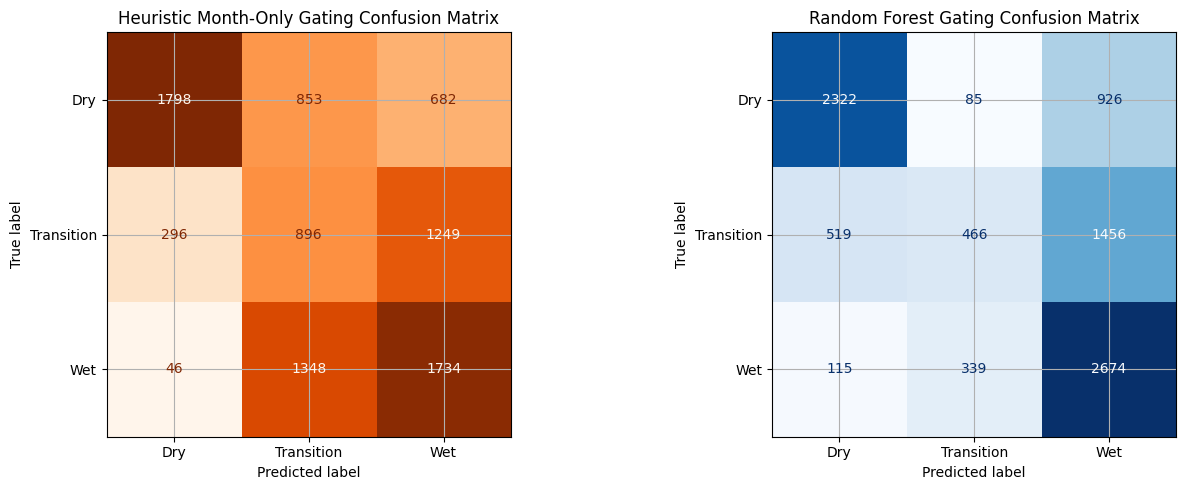

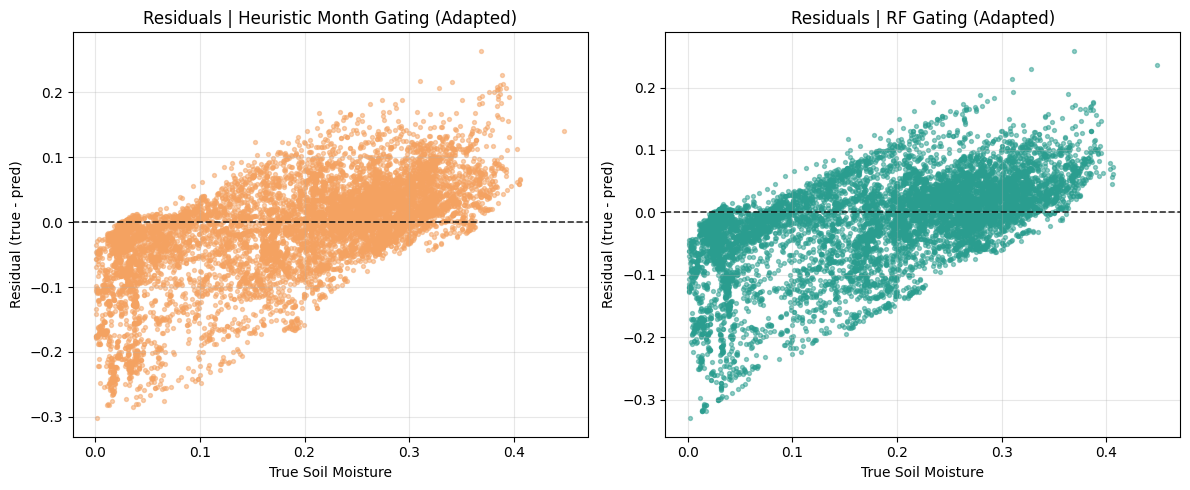

In [6]:
# Partition trainval using true thresholds
mask_dry_tv = y_trainval < T1
mask_transition_tv = (y_trainval >= T1) & (y_trainval < T2)
mask_wet_tv = y_trainval >= T2

# Train specialists on true splits
print("Training Dry Specialist (Oracle reference)...")
xgb_dry_oracle = XGBRegressor(**XGB_PARAMS_DRY)
xgb_dry_oracle.fit(
    trainval_df.loc[mask_dry_tv, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_dry_tv, TARGET_COL],
    sample_weight=w_trainval[mask_dry_tv],
    verbose=0
)

print("Training Transition Specialist (Oracle reference)...")
xgb_transition_oracle = XGBRegressor(**XGB_PARAMS_TRANSITION)
xgb_transition_oracle.fit(
    trainval_df.loc[mask_transition_tv, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_transition_tv, TARGET_COL],
    sample_weight=w_trainval[mask_transition_tv],
    verbose=0
)

print("Training Wet Specialist (Oracle reference)...")
xgb_wet_oracle = XGBRegressor(**XGB_PARAMS_WET)
xgb_wet_oracle.fit(
    trainval_df.loc[mask_wet_tv, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_wet_tv, TARGET_COL],
    sample_weight=w_trainval[mask_wet_tv],
    verbose=0
)

# Route predictions using true labels on test set
pred_dry_oracle_test = np.asarray(xgb_dry_oracle.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()
pred_trans_oracle_test = np.asarray(xgb_transition_oracle.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()
pred_wet_oracle_test = np.asarray(xgb_wet_oracle.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()

pred_oracle_3r = np.zeros_like(y_test)
pred_oracle_3r[y_gate_test_3r == 0] = pred_dry_oracle_test[y_gate_test_3r == 0]
pred_oracle_3r[y_gate_test_3r == 1] = pred_trans_oracle_test[y_gate_test_3r == 1]
pred_oracle_3r[y_gate_test_3r == 2] = pred_wet_oracle_test[y_gate_test_3r == 2]

metrics_oracle_3r = compute_additional_metrics(y_test, pred_oracle_3r)
print("\n===== 3-REGIME ORACLE GATING METRICS =====")
for k, v in metrics_oracle_3r.items():
    print(f"{k:10s}: {v:.5f}")

metrics_dashboard(
    y_test,
    pred_oracle_3r,
    name="Model 4 | 3R Oracle Hard Gated Model (Reference)"
)

# Plotting 3-Regime results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Heuristic Month Gating Confusion Matrix
cm_heuristic = confusion_matrix(y_gate_test_3r, heuristic_gates_test)
ConfusionMatrixDisplay(cm_heuristic, display_labels=["Dry", "Transition", "Wet"]).plot(
    ax=axes[0], cmap="Oranges", values_format="d", colorbar=False
)
axes[0].set_title("Heuristic Month-Only Gating Confusion Matrix")

# Plot Random Forest Gating Confusion Matrix
cm_rf = confusion_matrix(y_gate_test_3r, rf_gates_test_3r)
ConfusionMatrixDisplay(cm_rf, display_labels=["Dry", "Transition", "Wet"]).plot(
    ax=axes[1], cmap="Blues", values_format="d", colorbar=False
)
axes[1].set_title("Random Forest Gating Confusion Matrix")

plt.tight_layout()
os.makedirs(os.path.join(PROJECT_ROOT, "notebooks/experiment/derived_8.1_pos-eval-2.0"), exist_ok=True)
plt.savefig(os.path.join(PROJECT_ROOT, "notebooks/experiment/derived_8.1_pos-eval-2.0/gating_confusion_matrices.png"))
plt.show()

# Create residuals comparison plot for 3-regime models
residuals_heuristic = y_test - pred_heuristic_3r
residuals_rf = y_test - pred_rf_3r

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, residuals_heuristic, s=8, alpha=0.5, color='#f4a261')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals | Heuristic Month Gating (Adapted)")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, residuals_rf, s=8, alpha=0.5, color='#2a9d8f')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals | RF Gating (Adapted)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "notebooks/experiment/derived_8.1_pos-eval-2.0/residuals_3r.png"))
plt.show()

# Section 7: Model 5 - 2-Regime Random Forest Gated Model

In this section, we train a 2-Regime Random Forest Gating router (threshold $T_{2REGIME} = 0.159$) on the `trainval` split, predict 2-regime class assignments on the training data, train two specialists (`xgb_dry_rf2r`, `xgb_wet_rf2r`) on these imperfect training partitions, and evaluate the end-to-end performance.

In [7]:
# 2-Regime parameter dictionaries matching experiment 1.2 optimal parameters
XGB_PARAMS_DRY_2R = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=5,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

XGB_PARAMS_WET_2R = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=10,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.8,
    n_estimators=6000,
    learning_rate=0.03,
    reg_lambda=0.3,
    reg_alpha=0.0,
    gamma=0.0,
    device=XGB_DEVICE
)

# 1. Train gating classifier
y_gate_trainval_2r = np.where(y_trainval < T_2REGIME, 0, 1)
y_gate_test_2r = np.where(y_test < T_2REGIME, 0, 1)

print("Training Random Forest 2-Regime Gating Router...")
rf_gate_2r = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_gate_2r.fit(trainval_df[GATING_FEATURES], y_gate_trainval_2r)

# Predict gates on trainval
rf_gates_trainval_2r = rf_gate_2r.predict(trainval_df[GATING_FEATURES])
mask_dry_tv_rf2r = rf_gates_trainval_2r == 0
mask_wet_tv_rf2r = rf_gates_trainval_2r == 1

print("\nTrainval Split RF 2R Predicted Regime Distribution:")
print(f"  Dry Regime: {mask_dry_tv_rf2r.sum():,}")
print(f"  Wet Regime: {mask_wet_tv_rf2r.sum():,}")

# 2. Train 2R Specialists on imperfect training partitions
print("\nTraining Dry Specialist (2-Regime, RF Gated)...")
start_time = time.time()
xgb_dry_2r = XGBRegressor(**XGB_PARAMS_DRY_2R)
xgb_dry_2r.fit(
    trainval_df.loc[mask_dry_tv_rf2r, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_dry_tv_rf2r, TARGET_COL],
    sample_weight=w_trainval[mask_dry_tv_rf2r],
    verbose=0
)
print(f"Dry Specialist (2-Regime) training completed in {time.time() - start_time:.2f} seconds.")

print("Training Wet Specialist (2-Regime, RF Gated)...")
start_time = time.time()
xgb_wet_2r = XGBRegressor(**XGB_PARAMS_WET_2R)
xgb_wet_2r.fit(
    trainval_df.loc[mask_wet_tv_rf2r, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_wet_tv_rf2r, TARGET_COL],
    sample_weight=w_trainval[mask_wet_tv_rf2r],
    verbose=0
)
print(f"Wet Specialist (2-Regime) training completed in {time.time() - start_time:.2f} seconds.")

# 3. Predict on test split and route predictions
rf_gates_test_2r = rf_gate_2r.predict(test_df[GATING_FEATURES])

print("\nRandom Forest Gating Classification Report on Test Set:")
print(classification_report(y_gate_test_2r, rf_gates_test_2r, target_names=["Dry", "Wet"]))

pred_dry_test_2r = np.asarray(xgb_dry_2r.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()
pred_wet_test_2r = np.asarray(xgb_wet_2r.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()

pred_rf_2r = np.zeros_like(y_test)
pred_rf_2r[rf_gates_test_2r == 0] = pred_dry_test_2r[rf_gates_test_2r == 0]
pred_rf_2r[rf_gates_test_2r == 1] = pred_wet_test_2r[rf_gates_test_2r == 1]

metrics_rf_2r = compute_additional_metrics(y_test, pred_rf_2r)
print("\n===== 2-REGIME RANDOM FOREST GATING METRICS (ADAPTED TRAINING) =====")
for k, v in metrics_rf_2r.items():
    print(f"{k:10s}: {v:.5f}")

metrics_dashboard(
    y_test,
    pred_rf_2r,
    name="Model 5 | 2R Random Forest Gated Model (Adapted)"
)

Training Random Forest 2-Regime Gating Router...



Trainval Split RF 2R Predicted Regime Distribution:
  Dry Regime: 5,968
  Wet Regime: 17,145

Training Dry Specialist (2-Regime, RF Gated)...


Dry Specialist (2-Regime) training completed in 26.49 seconds.
Training Wet Specialist (2-Regime, RF Gated)...


Wet Specialist (2-Regime) training completed in 50.93 seconds.

Random Forest Gating Classification Report on Test Set:
              precision    recall  f1-score   support

         Dry       0.86      0.64      0.73      3333
         Wet       0.81      0.94      0.87      5569

    accuracy                           0.83      8902
   macro avg       0.83      0.79      0.80      8902
weighted avg       0.83      0.83      0.82      8902




===== 2-REGIME RANDOM FOREST GATING METRICS (ADAPTED TRAINING) =====
R2        : 0.52194
RMSE      : 0.07281
ubRMSE    : 0.07189
Bias      : -0.01154
MAE       : 0.05283
Med|Err|  : 0.03847
Pearson   : 0.73354


# Section 8: Model 6 - 2-Regime Oracle Gated Model (Baseline Reference)

In this section, we train the two 2-Regime specialists (`xgb_dry_2r_oracle`, `xgb_wet_2r_oracle`) on ground-truth subsets and route test predictions using the true test soil moisture class. This is equivalent to Model 6 from 1.2 (trained on overall features).

Training Dry Specialist (2R Oracle reference)...


Training Wet Specialist (2R Oracle reference)...



===== 2-REGIME ORACLE GATING METRICS =====
R2        : 0.77523
RMSE      : 0.04992
ubRMSE    : 0.04828
Bias      : -0.01269
MAE       : 0.03880
Med|Err|  : 0.03181
Pearson   : 0.88871


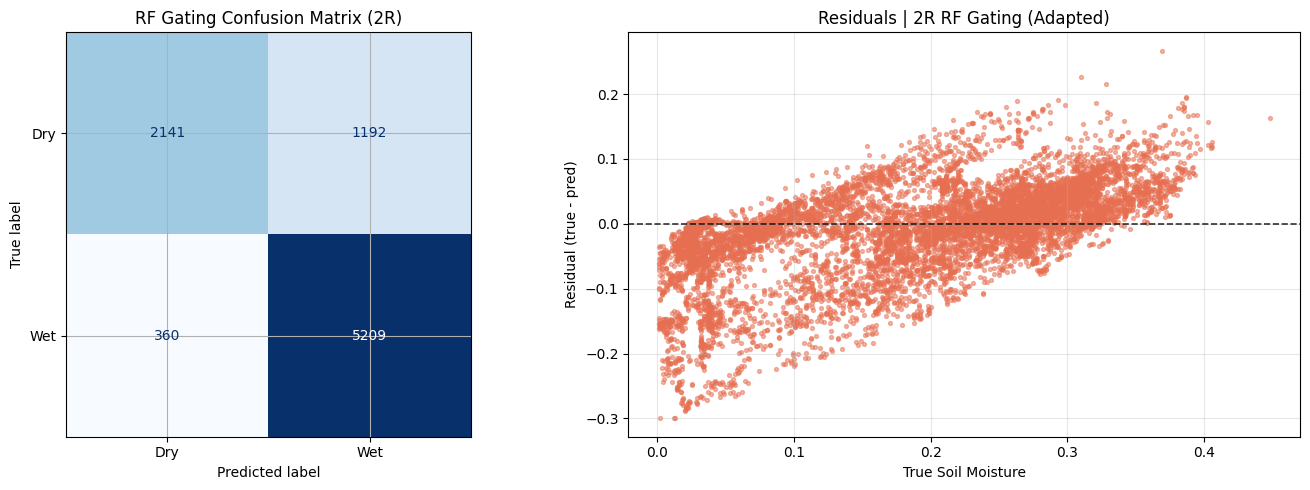

In [8]:
mask_dry_tv_2r = y_trainval < T_2REGIME
mask_wet_tv_2r = y_trainval >= T_2REGIME

print("Training Dry Specialist (2R Oracle reference)...")
xgb_dry_2r_oracle = XGBRegressor(**XGB_PARAMS_DRY_2R)
xgb_dry_2r_oracle.fit(
    trainval_df.loc[mask_dry_tv_2r, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_dry_tv_2r, TARGET_COL],
    sample_weight=w_trainval[mask_dry_tv_2r],
    verbose=0
)

print("Training Wet Specialist (2R Oracle reference)...")
xgb_wet_2r_oracle = XGBRegressor(**XGB_PARAMS_WET_2R)
xgb_wet_2r_oracle.fit(
    trainval_df.loc[mask_wet_tv_2r, OVERALL_SELECTED_FEATURES],
    trainval_df.loc[mask_wet_tv_2r, TARGET_COL],
    sample_weight=w_trainval[mask_wet_tv_2r],
    verbose=0
)

pred_dry_oracle_test_2r = np.asarray(xgb_dry_2r_oracle.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()
pred_wet_oracle_test_2r = np.asarray(xgb_wet_2r_oracle.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()

pred_oracle_2r = np.zeros_like(y_test)
pred_oracle_2r[y_gate_test_2r == 0] = pred_dry_oracle_test_2r[y_gate_test_2r == 0]
pred_oracle_2r[y_gate_test_2r == 1] = pred_wet_oracle_test_2r[y_gate_test_2r == 1]

metrics_oracle_2r = compute_additional_metrics(y_test, pred_oracle_2r)
print("\n===== 2-REGIME ORACLE GATING METRICS =====")
for k, v in metrics_oracle_2r.items():
    print(f"{k:10s}: {v:.5f}")

metrics_dashboard(
    y_test,
    pred_oracle_2r,
    name="Model 6 | 2R Oracle Hard Gated Model (Reference)"
)

# Plotting 2-Regime results
plt.figure(figsize=(14, 5))

# Plot RF Gating Confusion Matrix (2R)
plt.subplot(1, 2, 1)
cm_rf_2r = confusion_matrix(y_gate_test_2r, rf_gates_test_2r)
ConfusionMatrixDisplay(cm_rf_2r, display_labels=["Dry", "Wet"]).plot(
    ax=plt.gca(), cmap="Blues", values_format="d", colorbar=False
)
plt.title("RF Gating Confusion Matrix (2R)")

# Plot Residuals
plt.subplot(1, 2, 2)
residuals_rf_2r = y_test - pred_rf_2r
plt.scatter(y_test, residuals_rf_2r, s=8, alpha=0.5, color='#e76f51')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals | 2R RF Gating (Adapted)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "notebooks/experiment/derived_8.1_pos-eval-2.0/residuals_and_cm_2r.png"))
plt.show()

# Section 9: Comparative Results Summary

In this section, we compare all evaluated models on the Washington-only `derived_8.1_pos` test set (N=8,902).

In [9]:
# Construct summary metrics dataframe
metrics_summary_data = {
    "Model": [
        "Single Global XGBoost (No Gating)",
        "3-Regime Heuristic Month Gating (Adapted)",
        "3-Regime Random Forest Gating (Adapted)",
        "3-Regime Oracle Gating (Overall Features)",
        "2-Regime Random Forest Gating (Adapted)",
        "2-Regime Oracle Gating (Tuned 2R)"
    ],
    "R2": [
        global_metrics["R2"],
        metrics_heuristic_3r["R2"],
        metrics_rf_3r["R2"],
        metrics_oracle_3r["R2"],
        metrics_rf_2r["R2"],
        metrics_oracle_2r["R2"]
    ],
    "RMSE": [
        global_metrics["RMSE"],
        metrics_heuristic_3r["RMSE"],
        metrics_rf_3r["RMSE"],
        metrics_oracle_3r["RMSE"],
        metrics_rf_2r["RMSE"],
        metrics_oracle_2r["RMSE"]
    ],
    "ubRMSE": [
        global_metrics["ubRMSE"],
        metrics_heuristic_3r["ubRMSE"],
        metrics_rf_3r["ubRMSE"],
        metrics_oracle_3r["ubRMSE"],
        metrics_rf_2r["ubRMSE"],
        metrics_oracle_2r["ubRMSE"]
    ],
    "Bias": [
        global_metrics["Bias"],
        metrics_heuristic_3r["Bias"],
        metrics_rf_3r["Bias"],
        metrics_oracle_3r["Bias"],
        metrics_rf_2r["Bias"],
        metrics_oracle_2r["Bias"]
    ],
    "MAE": [
        global_metrics["MAE"],
        metrics_heuristic_3r["MAE"],
        metrics_rf_3r["MAE"],
        metrics_oracle_3r["MAE"],
        metrics_rf_2r["MAE"],
        metrics_oracle_2r["MAE"]
    ],
    "Med|Err|": [
        global_metrics["Med|Err|"],
        metrics_heuristic_3r["Med|Err|"],
        metrics_rf_3r["Med|Err|"],
        metrics_oracle_3r["Med|Err|"],
        metrics_rf_2r["Med|Err|"],
        metrics_oracle_2r["Med|Err|"]
    ],
    "Pearson": [
        global_metrics["Pearson"],
        metrics_heuristic_3r["Pearson"],
        metrics_rf_3r["Pearson"],
        metrics_oracle_3r["Pearson"],
        metrics_rf_2r["Pearson"],
        metrics_oracle_2r["Pearson"]
    ]
}

summary_df = pd.DataFrame(metrics_summary_data)

print("\n===== FINAL COMPARATIVE RESULTS SUMMARY (TEST SET N=8,902) =====")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(summary_df.to_string(index=False, formatters={
    'R2': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'ubRMSE': '{:,.4f}'.format,
    'Bias': '{:+,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'Med|Err|': '{:,.4f}'.format,
    'Pearson': '{:,.4f}'.format
}))

summary_df.to_csv(os.path.join(PROJECT_ROOT, "notebooks/experiment/derived_8.1_pos-eval-2.0/metrics_summary.csv"), index=False)
print("\nSummary metrics table successfully saved to CSV.")


===== FINAL COMPARATIVE RESULTS SUMMARY (TEST SET N=8,902) =====
                                    Model     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
        Single Global XGBoost (No Gating) 0.4858 0.0755 0.0745 -0.0120 0.0554   0.0395  0.7084
3-Regime Heuristic Month Gating (Adapted) 0.4690 0.0767 0.0759 -0.0112 0.0559   0.0400  0.6978
  3-Regime Random Forest Gating (Adapted) 0.4965 0.0747 0.0733 -0.0147 0.0537   0.0384  0.7243
3-Regime Oracle Gating (Overall Features) 0.8729 0.0375 0.0361 -0.0102 0.0296   0.0244  0.9393
  2-Regime Random Forest Gating (Adapted) 0.5219 0.0728 0.0719 -0.0115 0.0528   0.0385  0.7335
        2-Regime Oracle Gating (Tuned 2R) 0.7752 0.0499 0.0483 -0.0127 0.0388   0.0318  0.8887

Summary metrics table successfully saved to CSV.


# Section 10: Gating Router Classification Performance Summary

In this section, we evaluate the classification performance (accuracy, precision, recall, and F1-score) of the gating routers on the test set. This includes:
1. 3-Regime Heuristic Month-Only Gating Router
2. 3-Regime Random Forest Gating Router
3. 2-Regime Random Forest Gating Router

In [10]:
# Compute and summarize gating router classification metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_classifier_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "Accuracy": acc,
        "Precision (Macro)": prec_macro,
        "Recall (Macro)": rec_macro,
        "F1-Score (Macro)": f1_macro,
        "Precision (Weighted)": prec_weighted,
        "Recall (Weighted)": rec_weighted,
        "F1-Score (Weighted)": f1_weighted
    }

router_metrics = []
# 3R Heuristic
router_metrics.append({
    "Router": "3-Regime Heuristic Month Gating",
    **compute_classifier_metrics(y_gate_test_3r, heuristic_gates_test)
})
# 3R RF
router_metrics.append({
    "Router": "3-Regime Random Forest Gating",
    **compute_classifier_metrics(y_gate_test_3r, rf_gates_test_3r)
})
# 2R RF
router_metrics.append({
    "Router": "2-Regime Random Forest Gating",
    **compute_classifier_metrics(y_gate_test_2r, rf_gates_test_2r)
})

router_metrics_df = pd.DataFrame(router_metrics)

print("\n===== GATING ROUTER CLASSIFICATION PERFORMANCE SUMMARY =====")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(router_metrics_df.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format,
    'Precision (Macro)': '{:,.4f}'.format,
    'Recall (Macro)': '{:,.4f}'.format,
    'F1-Score (Macro)': '{:,.4f}'.format,
    'Precision (Weighted)': '{:,.4f}'.format,
    'Recall (Weighted)': '{:,.4f}'.format,
    'F1-Score (Weighted)': '{:,.4f}'.format
}))

router_metrics_df.to_csv(os.path.join(PROJECT_ROOT, "notebooks/experiment/derived_8.1_pos-eval-2.0/gating_router_metrics.csv"), index=False)
print("\nGating router metrics table successfully saved to CSV.")


===== GATING ROUTER CLASSIFICATION PERFORMANCE SUMMARY =====
                         Router Accuracy Precision (Macro) Recall (Macro) F1-Score (Macro) Precision (Weighted) Recall (Weighted) F1-Score (Weighted)
3-Regime Heuristic Month Gating   0.4974            0.5342         0.4870           0.4971               0.5602            0.4974              0.5141
  3-Regime Random Forest Gating   0.6136            0.6127         0.5808           0.5572               0.6235            0.6136              0.5828
  2-Regime Random Forest Gating   0.8257            0.8349         0.7889           0.8022               0.8296            0.8257              0.8193

Gating router metrics table successfully saved to CSV.


# Individual Specialist Residual Plots (3-Regime Models)

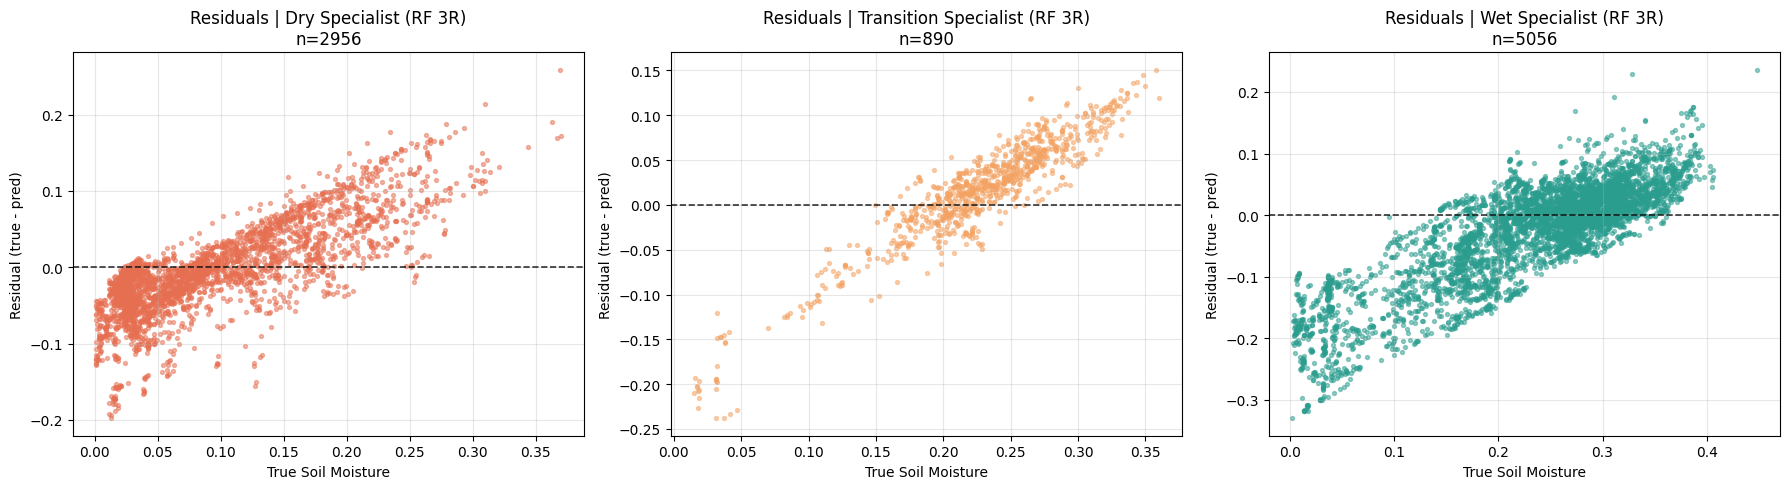

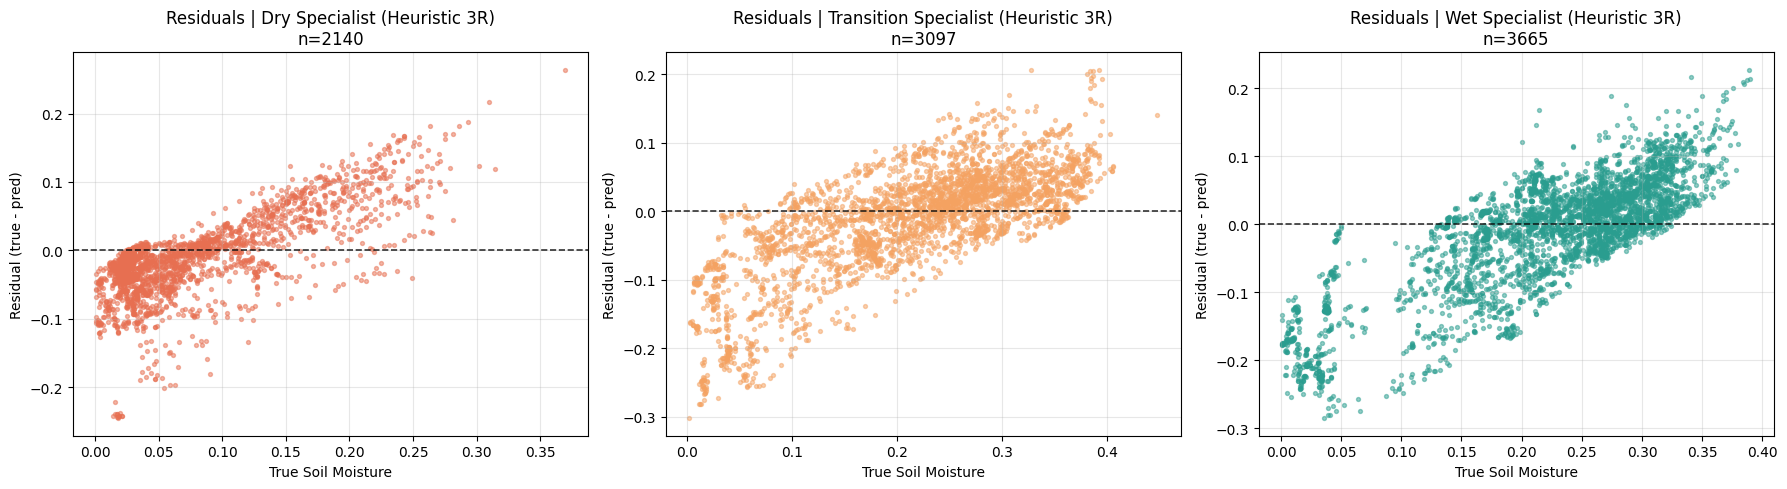

In [11]:
# Individual Specialist Residual Plots (3-Regime RF Gating)
# Masks based on actual routing decisions from RF gating model
mask_dry_rf3r = rf_gates_test_3r == 0
mask_transition_rf3r = rf_gates_test_3r == 1
mask_wet_rf3r = rf_gates_test_3r == 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dry Specialist
residuals_dry = y_test[mask_dry_rf3r] - pred_dry_rf3r_test[mask_dry_rf3r]
axes[0].scatter(y_test[mask_dry_rf3r], residuals_dry, s=8, alpha=0.5, color='#e76f51')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title(f"Residuals | Dry Specialist (RF 3R)\nn={mask_dry_rf3r.sum()}")
axes[0].grid(alpha=0.3)

# Transition Specialist
residuals_trans = y_test[mask_transition_rf3r] - pred_trans_rf3r_test[mask_transition_rf3r]
axes[1].scatter(y_test[mask_transition_rf3r], residuals_trans, s=8, alpha=0.5, color='#f4a261')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_ylabel("Residual (true - pred)")
axes[1].set_title(f"Residuals | Transition Specialist (RF 3R)\nn={mask_transition_rf3r.sum()}")
axes[1].grid(alpha=0.3)

# Wet Specialist
residuals_wet = y_test[mask_wet_rf3r] - pred_wet_rf3r_test[mask_wet_rf3r]
axes[2].scatter(y_test[mask_wet_rf3r], residuals_wet, s=8, alpha=0.5, color='#2a9d8f')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[2].set_xlabel("True Soil Moisture")
axes[2].set_ylabel("Residual (true - pred)")
axes[2].set_title(f"Residuals | Wet Specialist (RF 3R)\nn={mask_wet_rf3r.sum()}")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "notebooks/experiment/derived_8.1_pos-eval-2.0/specialist_residuals_3r_rf.png"))
plt.show()

# Individual Specialist Residual Plots (3-Regime Heuristic Gating)
# Masks based on actual routing decisions from heuristic gating model
mask_dry_heur = heuristic_gates_test == 0
mask_transition_heur = heuristic_gates_test == 1
mask_wet_heur = heuristic_gates_test == 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dry Specialist
residuals_dry_heur = y_test[mask_dry_heur] - pred_dry_heur_test[mask_dry_heur]
axes[0].scatter(y_test[mask_dry_heur], residuals_dry_heur, s=8, alpha=0.5, color='#e76f51')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title(f"Residuals | Dry Specialist (Heuristic 3R)\nn={mask_dry_heur.sum()}")
axes[0].grid(alpha=0.3)

# Transition Specialist
residuals_trans_heur = y_test[mask_transition_heur] - pred_trans_heur_test[mask_transition_heur]
axes[1].scatter(y_test[mask_transition_heur], residuals_trans_heur, s=8, alpha=0.5, color='#f4a261')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_ylabel("Residual (true - pred)")
axes[1].set_title(f"Residuals | Transition Specialist (Heuristic 3R)\nn={mask_transition_heur.sum()}")
axes[1].grid(alpha=0.3)

# Wet Specialist
residuals_wet_heur = y_test[mask_wet_heur] - pred_wet_heur_test[mask_wet_heur]
axes[2].scatter(y_test[mask_wet_heur], residuals_wet_heur, s=8, alpha=0.5, color='#2a9d8f')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[2].set_xlabel("True Soil Moisture")
axes[2].set_ylabel("Residual (true - pred)")
axes[2].set_title(f"Residuals | Wet Specialist (Heuristic 3R)\nn={mask_wet_heur.sum()}")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "notebooks/experiment/derived_8.1_pos-eval-2.0/specialist_residuals_3r_heuristic.png"))
plt.show()